In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
import tensorflow as tf
import os

base_dir = "/content/drive/MyDrive/Proyecto IA/Data"

train_dataset = tf.data.Dataset.load(os.path.join(base_dir, "train_dataset"))
val_dataset   = tf.data.Dataset.load(os.path.join(base_dir, "val_dataset"))

In [3]:
vocab_path = os.path.join(base_dir, "vocab.txt")

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = [line.strip() for line in f]

In [4]:
import numpy as np

vocab = np.array(vocab)
vocab[:20]

array(['', '[UNK]', 'i', 'feel', 'and', 'to', 'the', 'a', 'feeling',
       'that', 'of', 'my', 'in', 'it', 'like', 'so', 'for', 'im', 'have',
       'me'], dtype='<U20')

In [5]:
max_tokens = len(vocab)
max_tokens

10000

In [6]:
encoder = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens+2,
    output_sequence_length=100,
    vocabulary=vocab
)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=len(encoder.get_vocabulary()), output_dim=64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [8]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [9]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=val_dataset,
                    validation_steps=30)

Epoch 1/10
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - accuracy: 0.8363 - loss: 0.3839 - val_accuracy: 0.9721 - val_loss: 0.0587
Epoch 2/10
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9742 - loss: 0.0495 - val_accuracy: 0.9727 - val_loss: 0.0486
Epoch 3/10
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9759 - loss: 0.0423 - val_accuracy: 0.9727 - val_loss: 0.0505
Epoch 4/10
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9768 - loss: 0.0388 - val_accuracy: 0.9727 - val_loss: 0.0542
Epoch 5/10
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9779 - loss: 0.0365 - val_accuracy: 0.9727 - val_loss: 0.0502
Epoch 6/10
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9787 - loss: 0.0338 - val_accuracy: 0.9721 - val_loss: 0.0526
Epoch 7/10
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9796 - loss: 0.0322 - val_accuracy: 0.9734 - val_loss: 0.0545
Epoch 8/10
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9803 -

In [10]:
val_loss, val_acc = model.evaluate(val_dataset)

print('Test Loss:', val_loss)
print('Test Accuracy:', val_acc)

431/431 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9716 - loss: 0.0661
Test Loss: 0.06877139955759048
Test Accuracy: 0.9712480902671814


(0.0, 0.17403374323621393)

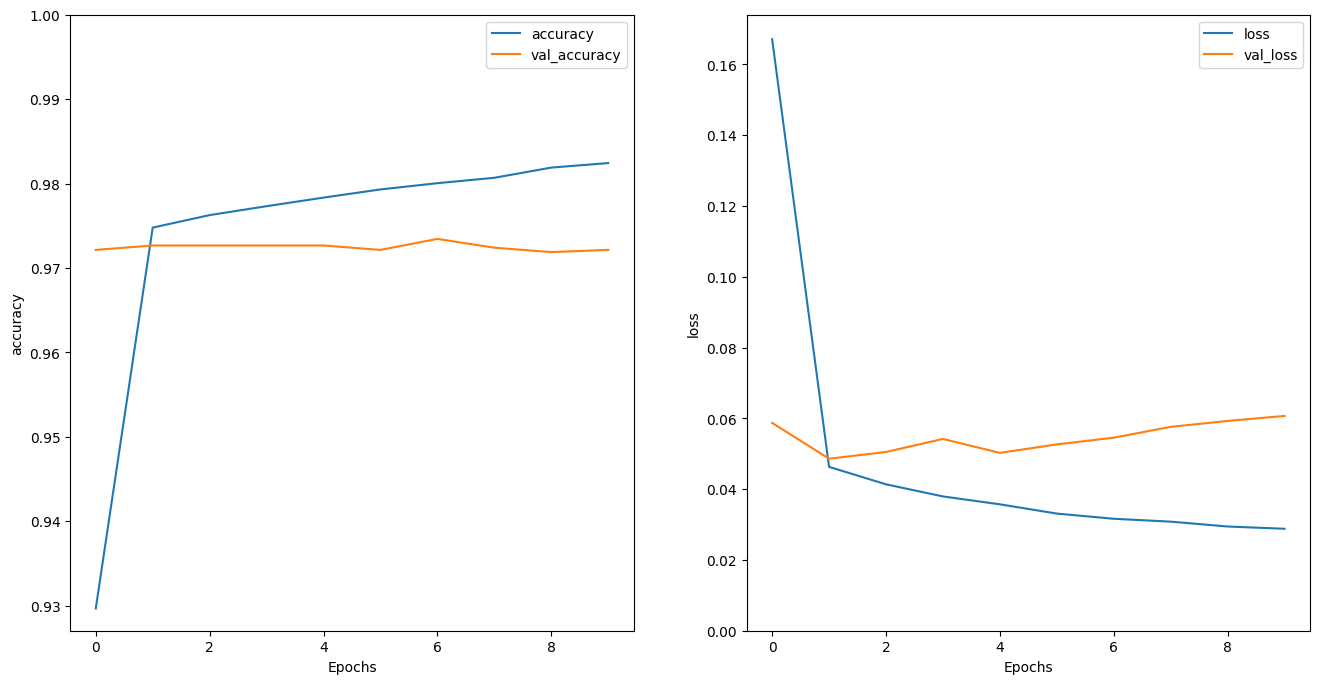

In [11]:
import matplotlib.pyplot as plt

def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

In [12]:
import os


model_path = os.path.join(base_dir, "feeling_model.keras")
model.save(model_path)

print(f"Modelo guardado correctamente en: {model_path}")

Modelo guardado correctamente en: /content/drive/MyDrive/Proyecto IA/Data/feeling_model.keras


In [13]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),  # incluye OOV; 0 se usa para padding
        output_dim=64,
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_cb = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history2 = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[earlystop_cb, checkpoint_cb]
)

Epoch 1/15
2005/2009 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8328 - loss: 0.3997
Epoch 1: val_loss improved from inf to 0.07145, saving model to best_model.keras
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.8331 - loss: 0.3991 - val_accuracy: 0.9686 - val_loss: 0.0715
Epoch 2/15
2007/2009 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9725 - loss: 0.0530
Epoch 2: val_loss improved from 0.07145 to 0.04724, saving model to best_model.keras
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9725 - loss: 0.0530 - val_accuracy: 0.9742 - val_loss: 0.0472
Epoch 3/15
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9761 - loss: 0.0418
Epoch 3: val_loss improved from 0.04724 to 0.04702, saving model to best_model.keras
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9761 - loss: 0.0418 - val_accuracy: 0.9745 - val_loss: 0.0470
Epoch 4/15
2009/2009 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9769 - loss: 0.0383
Epoch 4: val_loss did not impr

In [16]:
val_loss, val_acc = model2.evaluate(val_dataset)

print('Test Loss:', val_loss)
print('Test Accuracy:', val_acc)

431/431 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9744 - loss: 0.0459
Test Loss: 0.04702337831258774
Test Accuracy: 0.9744971990585327


(0.0, 0.1858596106991172)

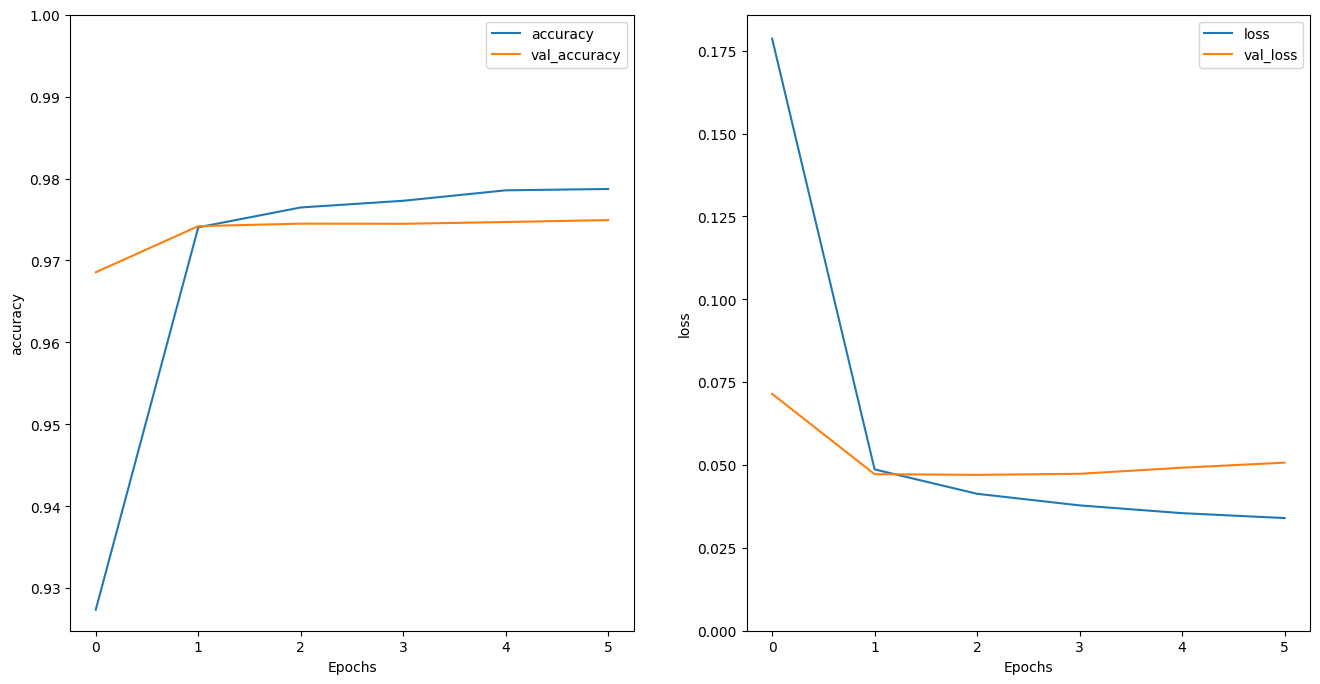

In [17]:
import matplotlib.pyplot as plt

def plot_graphs(history2, metric):
  plt.plot(history2.history[metric])
  plt.plot(history2.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history2, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history2, 'loss')
plt.ylim(0, None)

In [18]:
import os


model_path = os.path.join(base_dir, "feeling_model_2.keras")
model.save(model_path)

print(f"Modelo guardado correctamente en: {model_path}")

Modelo guardado correctamente en: /content/drive/MyDrive/Proyecto IA/Data/feeling_model_2.keras
